In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset_path = os.path.join("..", "dataset")

train_path = os.path.join(dataset_path, "train")
val_path = os.path.join(dataset_path, "val")
test_path = os.path.join(dataset_path, "test")

In [3]:
IMG_SIZE = 224

### Read and Resize One Image

In [4]:
normal_path = os.path.join(train_path, "NORMAL")

image = os.listdir(normal_path)[0]

img = cv2.imread(os.path.join(normal_path, image))

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

print(img.shape)

(224, 224, 3)


In [5]:
img = img / 255.0

print(img.min())
print(img.max())

0.0
1.0


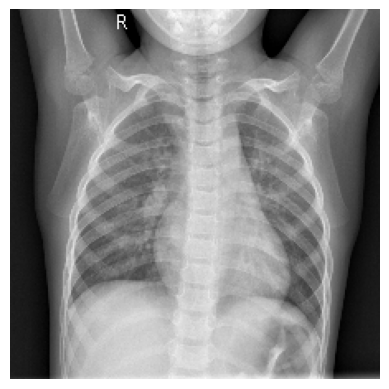

In [7]:
plt.imshow(img)
plt.axis("off")
plt.show()

In [8]:
images = []
labels = []

classes = ["NORMAL", "PNEUMONIA"]

for label, cls in enumerate(classes):

    folder = os.path.join(train_path, cls)

    for file in os.listdir(folder):

        img = cv2.imread(os.path.join(folder, file))

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (224,224))

        img = img / 255.0

        images.append(img)

        labels.append(label)

x_train = np.array(images, dtype=np.float32)
y_train = np.array(labels)

print(x_train.shape)
print(y_train.shape)

(5216, 224, 224, 3)
(5216,)


In [9]:
label_map = {
    0: "NORMAL",
    1: "PNEUMONIA"
}

print(label_map)

{0: 'NORMAL', 1: 'PNEUMONIA'}


In [10]:
print(x_train.min())
print(x_train.max())

print(np.unique(y_train))

0.0
1.0
[0 1]


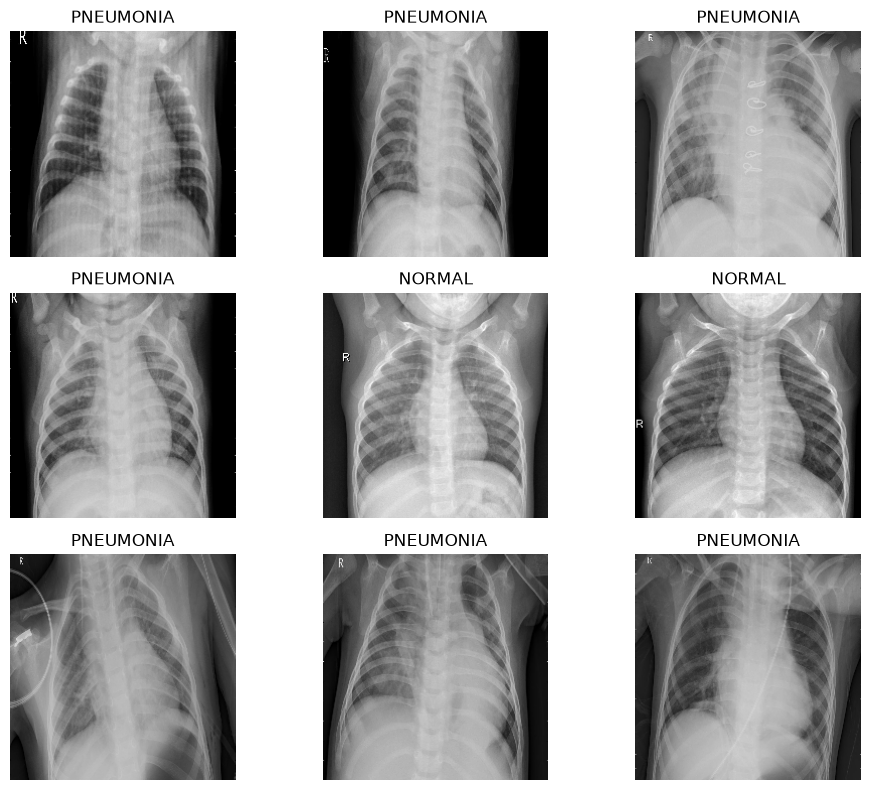

In [11]:
plt.figure(figsize=(10,8))

for i in range(9):

    index = np.random.randint(len(x_train))

    plt.subplot(3,3,i+1)

    plt.imshow(x_train[index])

    plt.title(label_map[y_train[index]])

    plt.axis("off")

plt.tight_layout()

plt.show()